#📌 Extracción

In [77]:
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Cargar datos
df = pd.read_json(url)

# Visualizar primeras filas
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [78]:
# Información general
df.info()

# Tipos de datos
df.dtypes

# Ver nombres de columnas
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [79]:
# Expandir columna customer
customer_df = pd.json_normalize(df['customer'])
customer_df.columns = ['customer_' + col for col in customer_df.columns]

# Expandir columna phone
phone_df = pd.json_normalize(df['phone'])
phone_df.columns = ['phone_' + col for col in phone_df.columns]

# Expandir columna internet
internet_df = pd.json_normalize(df['internet'])
internet_df.columns = ['internet_' + col for col in internet_df.columns]

# Expandir columna account
account_df = pd.json_normalize(df['account'])
account_df.columns = ['account_' + col for col in account_df.columns]

In [80]:
# Unir todas las columnas nuevas al dataframe original
df = pd.concat([df, customer_df, phone_df, internet_df, account_df], axis=1)

# Eliminar las columnas originales anidadas
df.drop(columns=['customer', 'phone', 'internet', 'account'], inplace=True)

In [81]:
# Revisar estructura
df.info()

# Ver primeras filas
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [82]:
#Valores nulos
df.isnull().sum()

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


In [83]:
#Valores duplicados
df.duplicated().sum()

np.int64(0)

In [84]:
#Categorías inconsistentes
for col in df.select_dtypes(include='object'):
    print(f"\nColumna: {col}")
    print(df[col].unique())


Columna: customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

Columna: Churn
['No' 'Yes' '']

Columna: customer_gender
['Female' 'Male']

Columna: customer_Partner
['Yes' 'No']

Columna: customer_Dependents
['Yes' 'No']

Columna: phone_PhoneService
['Yes' 'No']

Columna: phone_MultipleLines
['No' 'Yes' 'No phone service']

Columna: internet_InternetService
['DSL' 'Fiber optic' 'No']

Columna: internet_OnlineSecurity
['No' 'Yes' 'No internet service']

Columna: internet_OnlineBackup
['Yes' 'No' 'No internet service']

Columna: internet_DeviceProtection
['No' 'Yes' 'No internet service']

Columna: internet_TechSupport
['Yes' 'No' 'No internet service']

Columna: internet_StreamingTV
['Yes' 'No' 'No internet service']

Columna: internet_StreamingMovies
['No' 'Yes' 'No internet service']

Columna: account_Contract
['One year' 'Month-to-month' 'Two year']

Columna: account_PaperlessBilling
['Yes' 'No']

Columna: account_PaymentMethod
['Mailed che

In [85]:
# Reemplazar vacío por NaN
df['Churn'] = df['Churn'].replace('', pd.NA)

# Verificar
df['Churn'].value_counts(dropna=False)

,count
Churn,
No,5174
Yes,1869
<NA>,224


In [86]:
# Convertir account_Charges.Total a numérico
df['account_Charges.Total'] = pd.to_numeric(df['account_Charges.Total'], errors='coerce')

# Verificar tipo
df['account_Charges.Total'].dtype

dtype('float64')

In [87]:
# Crear columna de cuentas diarias
df['Cuentas_Diarias'] = df['account_Charges.Monthly'] / 30

df[['account_Charges.Monthly', 'Cuentas_Diarias']].head()

,account_Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [88]:
# Convertir Churn a binario
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Convertir columnas binarias
binary_cols = [
    'customer_Partner',
    'customer_Dependents',
    'phone_PhoneService',
    'account_PaperlessBilling'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [89]:
df.isnull().sum()

,0
customerID,0
Churn,224
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


In [90]:
# Eliminar filas sin Churn
df = df.dropna(subset=['Churn'])

# Eliminar filas sin account_Charges.Total
df = df.dropna(subset=['account_Charges.Total'])

In [91]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


In [92]:
# Renombrar las columnas

df = df.rename(columns={
    'customerID': 'CustomerID',
    'Churn': 'Churn',
    'customer_gender': 'Gender',
    'customer_SeniorCitizen': 'SeniorCitizen',
    'customer_Partner': 'Partner',
    'customer_Dependents': 'Dependents',
    'customer_tenure': 'Tenure',
    'phone_PhoneService': 'PhoneService',
    'phone_MultipleLines': 'MultipleLines',
    'internet_InternetService': 'InternetService',
    'internet_OnlineSecurity': 'OnlineSecurity',
    'internet_OnlineBackup': 'OnlineBackup',
    'internet_DeviceProtection': 'DeviceProtection',
    'internet_TechSupport': 'TechSupport',
    'internet_StreamingTV': 'StreamingTV',
    'internet_StreamingMovies': 'StreamingMovies',
    'account_Contract': 'Contract',
    'account_PaperlessBilling': 'PaperlessBilling',
    'account_PaymentMethod': 'PaymentMethod',
    'account_Charges.Monthly': 'MonthlyCharges',
    'account_Charges.Total': 'TotalCharges',
    'Cuentas_Diarias': 'DailyCharges'
})

In [93]:
df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,DailyCharges
0,0002-ORFBO,0.0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0.0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


#📊 Carga y análisis

In [96]:
# Estadísticas generales de variables numéricas
print("General Descriptive Statistics:")
print(df.describe())

# Mediana explícita
print("\nMedian of Numerical Variables:")
print(df.median(numeric_only=True))

# Desviación estándar
print("\nStandard Deviation:")
print(df.std(numeric_only=True))

# Analizar churn (proporción de evasión)
print("\nChurn Distribution:")
print(df['Churn'].value_counts())

print("\nChurn Proportion (%):")
print(df['Churn'].value_counts(normalize=True) * 100)

# Promedios agrupados por Churn
print("\nAverage Values Grouped by Churn:")
print(df.groupby('Churn').mean(numeric_only=True))

General Descriptive Statistics:
             Churn  SeniorCitizen      Partner   Dependents       Tenure  \
count  7032.000000    7032.000000  7032.000000  7032.000000  7032.000000   
mean      0.265785       0.162400     0.482509     0.298493    32.421786   
std       0.441782       0.368844     0.499729     0.457629    24.545260   
min       0.000000       0.000000     0.000000     0.000000     1.000000   
25%       0.000000       0.000000     0.000000     0.000000     9.000000   
50%       0.000000       0.000000     0.000000     0.000000    29.000000   
75%       1.000000       0.000000     1.000000     1.000000    55.000000   
max       1.000000       1.000000     1.000000     1.000000    72.000000   

       PhoneService  PaperlessBilling  MonthlyCharges  TotalCharges  \
count   7032.000000       7032.000000     7032.000000   7032.000000   
mean       0.903299          0.592719       64.798208   2283.300441   
std        0.295571          0.491363       30.085974   2266.771362   

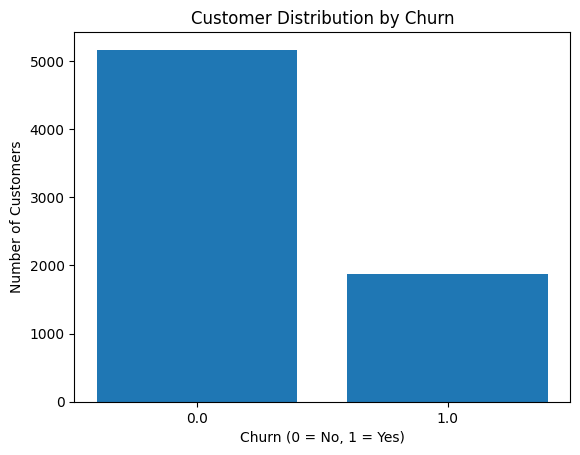

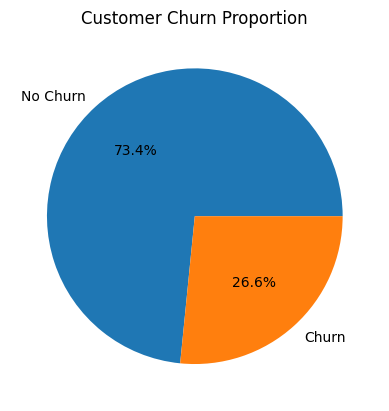

In [98]:
import matplotlib.pyplot as plt

churn_counts = df['Churn'].value_counts()

# Crear figura 1: Gráfico de barras
plt.figure()
plt.bar(churn_counts.index.astype(str), churn_counts.values)
plt.title("Customer Distribution by Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()


# Crear figura 2: Gráfico circular
plt.figure()
plt.pie(
    churn_counts.values,
    labels=["No Churn", "Churn"],
    autopct='%1.1f%%'
)
plt.title("Customer Churn Proportion")
plt.show()

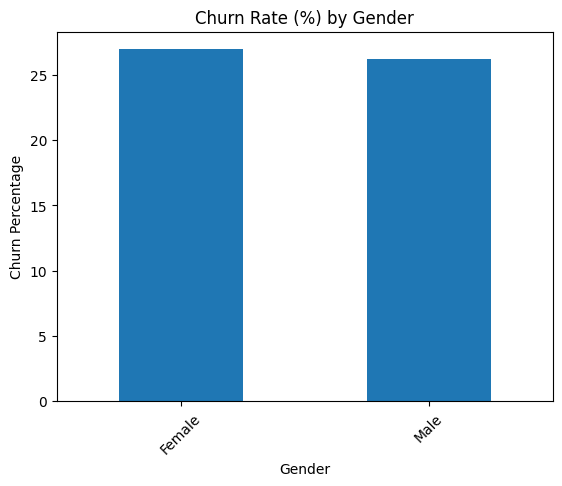

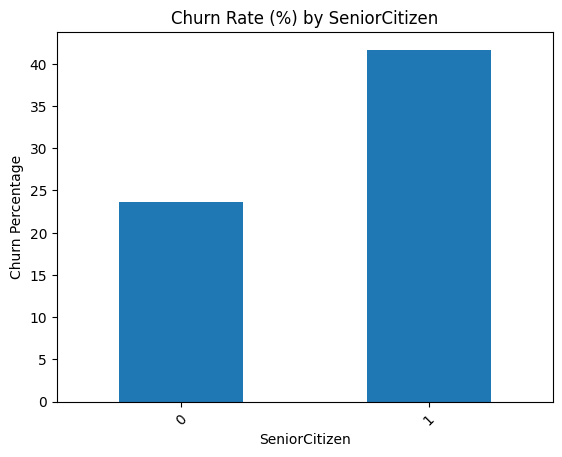

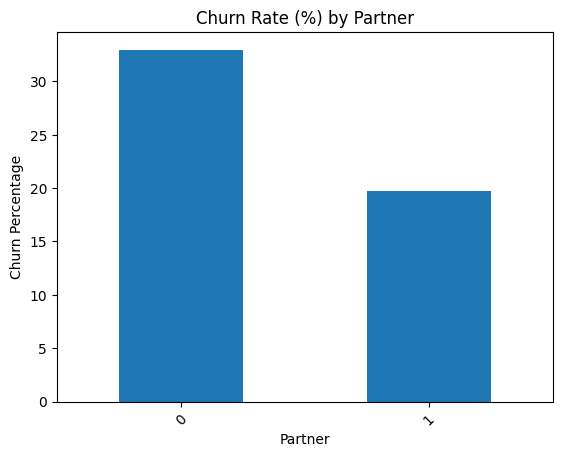

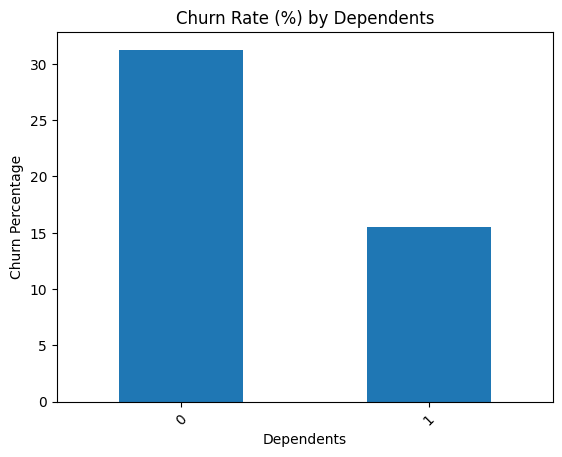

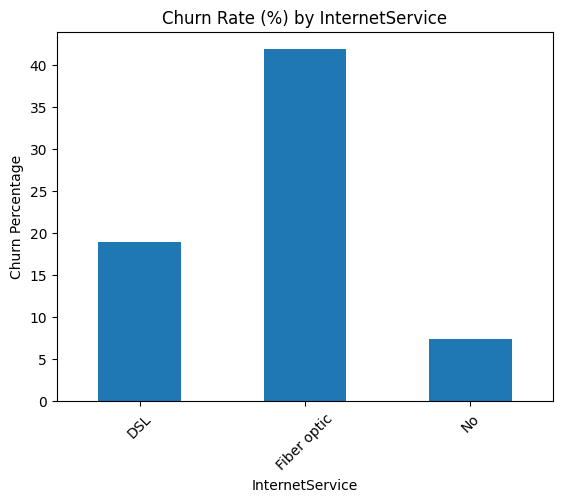

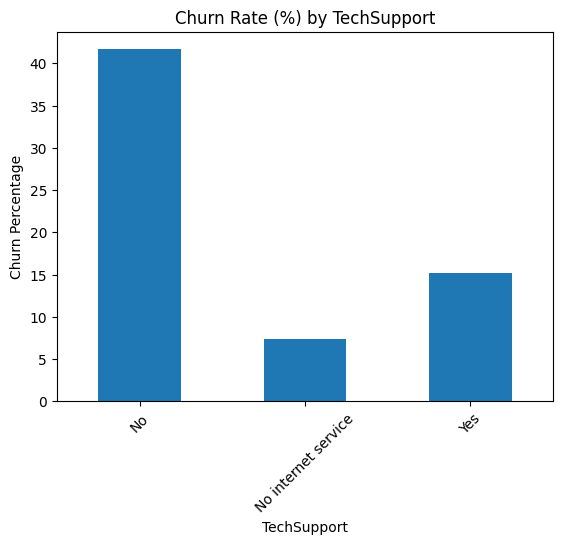

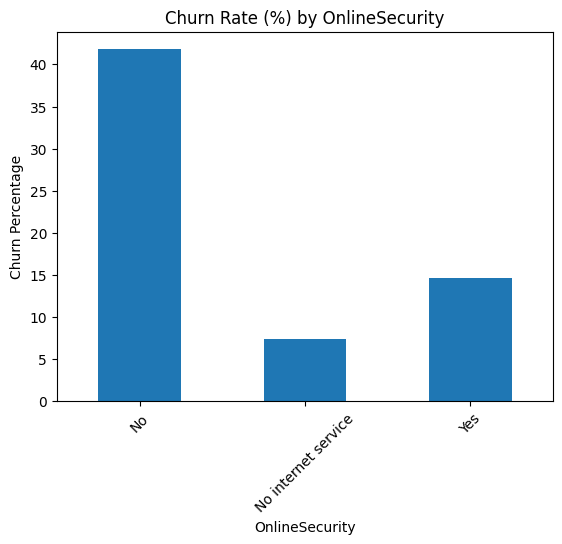

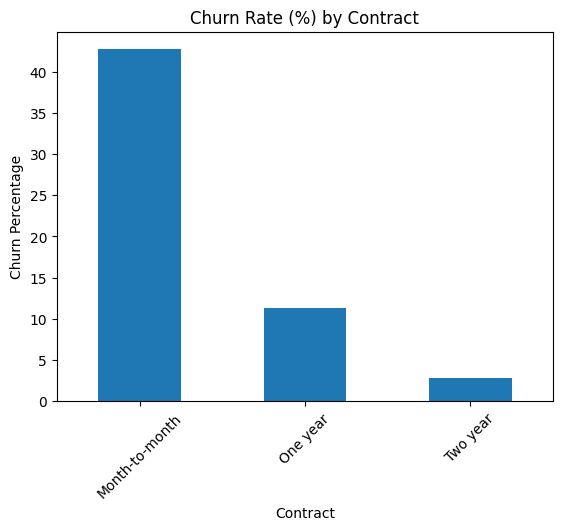

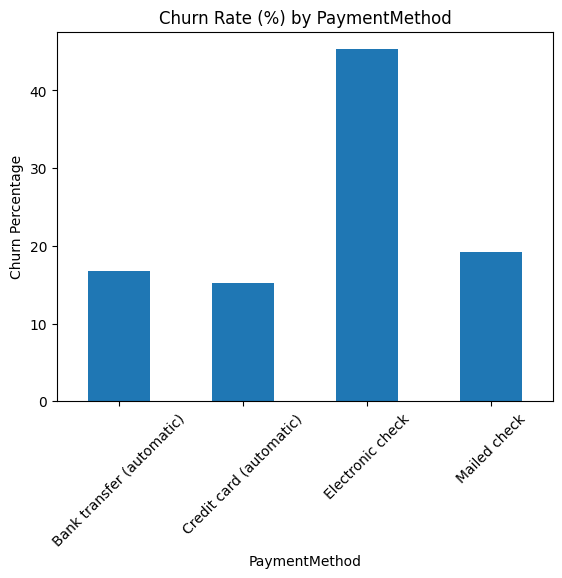

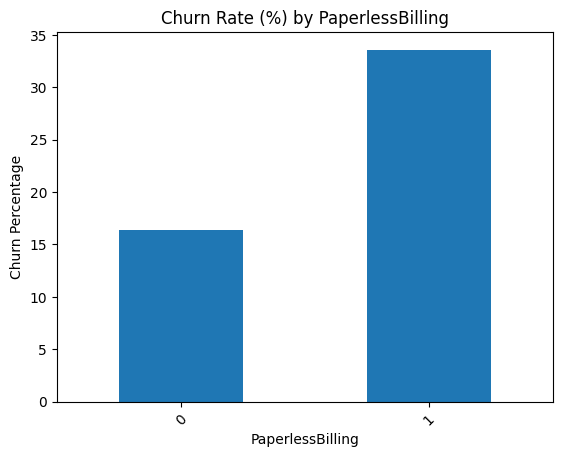

In [102]:
# Lista de variables categóricas para análisis de churn
categorical_vars = [
    'Gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'InternetService',
    'TechSupport',
    'OnlineSecurity',
    'Contract',
    'PaymentMethod',
    'PaperlessBilling'
]

for var in categorical_vars:

    churn_rate = df.groupby(var)['Churn'].mean() * 100

    # Crear gráfico
    plt.figure()
    churn_rate.plot(kind='bar')
    plt.title(f"Churn Rate (%) by {var}")
    plt.ylabel("Churn Percentage")
    plt.xlabel(var)
    plt.xticks(rotation=45)
    plt.show()

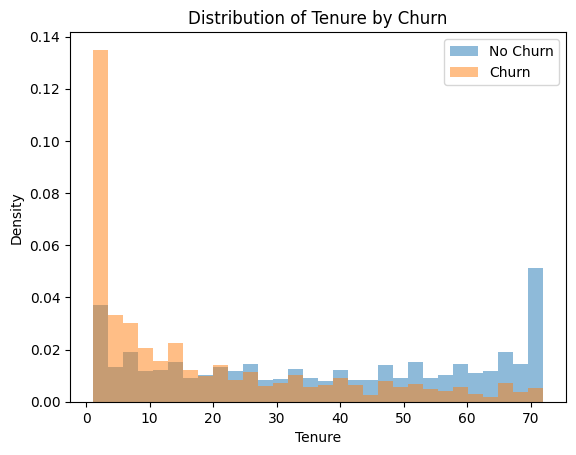

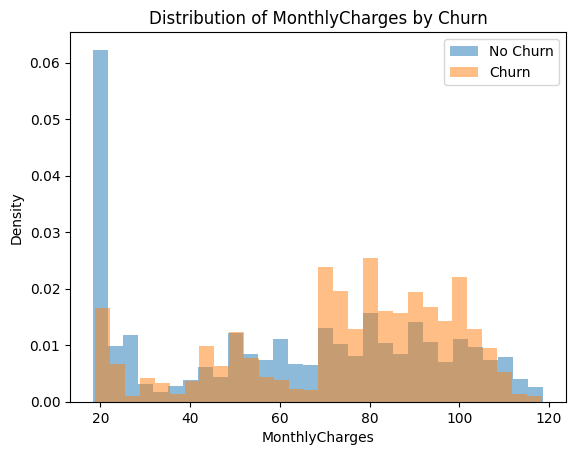

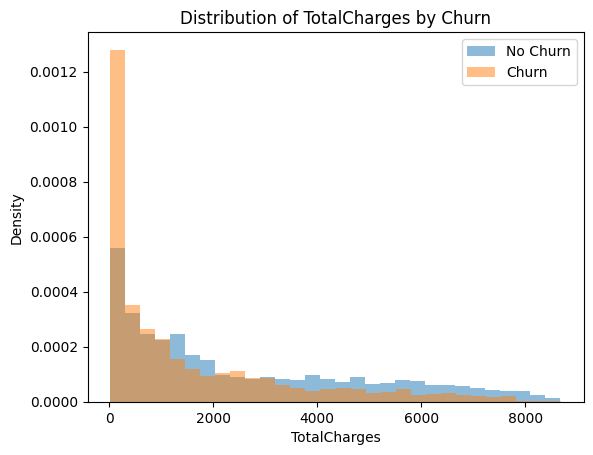

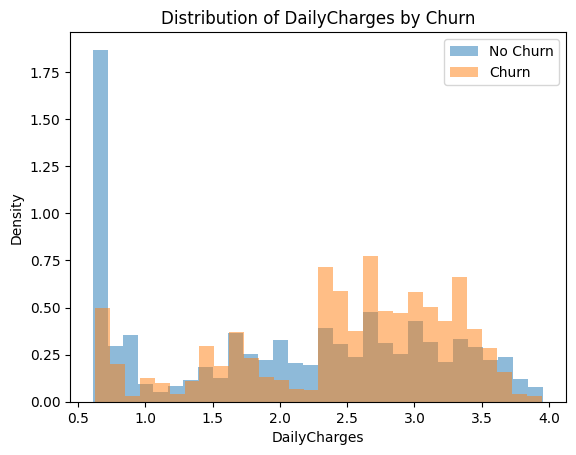

In [103]:
# Lista de variables numéricas
numeric_vars = [
    'Tenure',
    'MonthlyCharges',
    'TotalCharges',
    'DailyCharges'
]

for var in numeric_vars:

    plt.figure()

    # Clientes que NO cancelaron
    plt.hist(df[df['Churn'] == 0][var], bins=30, alpha=0.5,
             label='No Churn', density=True)

    # Clientes que cancelaron
    plt.hist(df[df['Churn'] == 1][var], bins=30, alpha=0.5,
             label='Churn', density=True)

    plt.title(f"Distribution of {var} by Churn")
    plt.xlabel(var)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

#📄Informe final

# 📊 Informe Final — Análisis de Evasión de Clientes (Churn)

---

## 🔹 Introducción

El objetivo de este análisis es estudiar el fenómeno de **evasión de clientes (Churn)** en la empresa Telecom X LATAM.  
El churn representa a aquellos clientes que deciden cancelar el servicio, lo cual constituye un problema crítico para las compañías de telecomunicaciones debido al impacto directo en los ingresos y en la estabilidad del negocio.

A través del análisis de datos, se busca identificar patrones y características asociadas a los clientes que abandonan el servicio, con el fin de generar **insights accionables** que permitan reducir la tasa de cancelación y mejorar la retención de clientes.

La variable objetivo del análisis es:

- **Churn**
  - 0 → Cliente permanece
  - 1 → Cliente cancela el servicio

---

## 🔹 Limpieza y Tratamiento de Datos

El proceso comenzó con la importación del dataset en formato JSON y su posterior transformación para facilitar el análisis.

### Pasos realizados:

### 1️⃣ Importación de datos
- Se cargaron los datos utilizando `pandas`.
- El dataset contenía columnas anidadas (`customer`, `phone`, `internet`, `account`).

### 2️⃣ Normalización de datos
- Se expandieron las columnas JSON utilizando `pd.json_normalize`.
- Se unificaron todas las variables en un único DataFrame.
- Se eliminaron las columnas originales anidadas.

### 3️⃣ Revisión de calidad de datos
Se verificaron:
- Valores nulos
- Registros duplicados
- Categorías inconsistentes

Resultados:
- No se encontraron duplicados.
- Existían valores vacíos en la variable **Churn**.
- La variable `TotalCharges` estaba almacenada como texto.

### 4️⃣ Transformaciones realizadas
- Conversión de `TotalCharges` a formato numérico.
- Reemplazo de valores vacíos por `NaN`.
- Eliminación de registros incompletos.
- Codificación binaria de variables categóricas (Yes/No → 1/0).
- Conversión de la variable objetivo `Churn` a formato binario.
- Creación de una nueva variable:
  
  **DailyCharges** = MonthlyCharges / 30

### 5️⃣ Renombrado de columnas
Se renombraron variables para mejorar la legibilidad y consistencia del dataset.

Luego del proceso, el dataset quedó limpio, estructurado y listo para el análisis exploratorio.

---

## 🔹 Análisis Exploratorio de Datos (EDA)

El análisis exploratorio permitió comprender la distribución de clientes y detectar factores asociados al churn.

### 📌 Distribución general del Churn

- Clientes activos: **73.4%**
- Clientes que cancelaron: **26.6%**

Esto indica una tasa de evasión significativa que justifica el análisis.

---

### 📊 Variables relevantes analizadas

Se identificaron como variables clave:

- Contract
- Tenure (antigüedad del cliente)
- MonthlyCharges
- PaymentMethod
- InternetService
- SeniorCitizen

---

### 📈 Hallazgos principales del análisis visual

#### ✅ Antigüedad del cliente (Tenure)
- Clientes con menor antigüedad presentan mayor churn.
- Los clientes antiguos muestran mayor fidelización.

#### ✅ Tipo de contrato
- Contratos **Month-to-month** presentan la mayor tasa de cancelación.
- Contratos anuales y bianuales reducen significativamente el churn.

#### ✅ Cargos mensuales
- Clientes con cargos mensuales más altos tienden a cancelar más frecuentemente.

#### ✅ Método de pago
- El método **Electronic check** muestra mayor tasa de evasión.
- Pagos automáticos presentan menor churn.

#### ✅ Servicios adicionales
- Clientes sin:
  - Online Security
  - Tech Support  
  presentan mayor probabilidad de abandono.

#### ✅ Facturación electrónica
- Usuarios con Paperless Billing tienen mayor churn relativo.

---

## 🔹 Conclusiones e Insights

A partir del análisis realizado se identifican patrones claros asociados a la evasión:

1. **El churn ocurre principalmente en etapas tempranas del cliente.**
2. **Los contratos mensuales generan menor compromiso del usuario.**
3. **Costos elevados aumentan la probabilidad de cancelación.**
4. **La falta de servicios de soporte y seguridad incrementa el abandono.**
5. **Los métodos de pago manuales están asociados a mayor churn.**

En general, el churn parece estar relacionado con una combinación de:
- Bajo compromiso contractual
- Alto costo percibido
- Baja percepción de valor del servicio

---

## 🔹 Recomendaciones Estratégicas

Basado en los hallazgos obtenidos, se proponen las siguientes acciones:

### 🎯 1. Incentivar contratos de largo plazo
- Ofrecer descuentos en contratos anuales o bianuales.

### 🎯 2. Estrategias de retención temprana
- Seguimiento activo durante los primeros meses del cliente.
- Ofertas personalizadas para clientes nuevos.

### 🎯 3. Paquetes de valor agregado
- Los clientes sin servicios adicionales presentan mayores tasas de evasión. Se recomienda incentivar la adopción temprana de servicios complementarios, ya que podrían aumentar la permanencia del cliente.

### 🎯 4. Optimizar métodos de pago
- Incentivar pagos automáticos mediante beneficios o descuentos.

### 🎯 5. Segmentación predictiva
- Utilizar modelos de Machine Learning para identificar clientes con alto riesgo de churn y actuar preventivamente.

---

## ✅ Conclusión Final

El análisis permitió comprender los factores principales que influyen en la evasión de clientes en Telecom X LATAM.  
Los resultados muestran que la retención puede mejorarse mediante estrategias enfocadas en compromiso contractual, mejora del valor percibido y acciones preventivas basadas en datos.

El uso de análisis exploratorio y visualizaciones permitió transformar datos crudos en información estratégica útil para la toma de decisiones empresariales.

---